In [4]:
import pandas as pd
import numpy as np

pokemon = pd.read_csv("pokemon.csv")
combats = pd.read_csv("combats.csv")

In [5]:
pokemon.head()


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [6]:
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [7]:
pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [8]:
combats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   50000 non-null  int64
 1   Second_pokemon  50000 non-null  int64
 2   Winner          50000 non-null  int64
dtypes: int64(3)
memory usage: 1.1 MB


In [9]:
pokemon.loc[pokemon["Name"].isnull(), "Name"] = "Primeape"

In [10]:
pokemon["Type 2"] = pokemon["Type 2"].fillna("None")
pokemon["Type 2"].isnull().sum()

np.int64(0)

In [11]:
wins = combats["Winner"].value_counts()
wins.head()

,count
Winner,
163,152
438,136
154,136
428,134
314,133


In [12]:
total_battles = pd.concat([combats["First_pokemon"], combats["Second_pokemon"]]).value_counts()
total_battles.head()

,count
163,164
344,160
667,159
214,158
758,158


In [13]:
win_percentage = wins / total_battles
win_percentage.head()

,count
1,0.278195
2,0.380165
3,0.674242
4,0.560000
5,0.491071


In [14]:
pokemon["win_percentage"] = pokemon["#"].map(win_percentage)
pokemon[["#", "Name", "win_percentage"]].head()

,#,Name,win_percentage
0,1,Bulbasaur,0.278195
1,2,Ivysaur,0.380165
2,3,Venusaur,0.674242
3,4,Mega Venusaur,0.560000
4,5,Charmander,0.491071


In [16]:
missing_count = pokemon["win_percentage"].isna().sum()
missing_count

np.int64(17)

In [18]:
missing_win_df = pokemon[pokemon["win_percentage"].isna()]
missing_win_df[["#", "Name", "win_percentage"]]

,#,Name,win_percentage
11,12,Blastoise,NaN
32,33,Sandshrew,NaN
45,46,Wigglytuff,NaN
65,66,Poliwag,NaN
77,78,Victreebel,NaN
89,90,Magneton,NaN
143,144,Ditto,NaN
182,183,Ariados,NaN
230,231,Shuckle,NaN
235,236,Ursaring,NaN


In [20]:
pokemon_model = pokemon.dropna(subset=["win_percentage"])
pokemon_model["win_percentage"].isna().sum()

np.int64(0)

In [21]:
pokemon.shape

(800, 13)

In [22]:
pokemon_model.shape

(783, 13)

In [24]:
numeric_columns = pokemon_model.select_dtypes(include=["int64", "float64"])
numeric_columns.columns

Index(['#', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed',
       'Generation', 'win_percentage'],
      dtype='object')

In [27]:
correlation_matrix = numeric_columns.corr()
correlation_matrix

,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,win_percentage
#,1.000000,0.101949,0.103613,0.101527,0.088006,0.088499,0.007267,0.983272,0.059498
HP,0.101949,1.000000,0.417427,0.265230,0.363244,0.409110,0.179423,0.060534,0.258006
Attack,0.103613,0.417427,1.000000,0.464539,0.395211,0.288078,0.382310,0.050805,0.500181
Defense,0.101527,0.265230,0.464539,1.000000,0.237592,0.490118,0.025762,0.048046,0.129426
Sp. Atk,0.088006,0.363244,0.395211,0.237592,1.000000,0.529276,0.470548,0.034729,0.478940
Sp. Def,0.088499,0.409110,0.288078,0.490118,0.529276,1.000000,0.276715,0.030303,0.324218
Speed,0.007267,0.179423,0.382310,0.025762,0.470548,0.276715,1.000000,-0.028512,0.937742
Generation,0.983272,0.060534,0.050805,0.048046,0.034729,0.030303,-0.028512,1.000000,0.021021
win_percentage,0.059498,0.258006,0.500181,0.129426,0.478940,0.324218,0.937742,0.021021,1.000000


In [29]:
win_corr = correlation_matrix["win_percentage"]
win_corr

,win_percentage
#,0.059498
HP,0.258006
Attack,0.500181
Defense,0.129426
Sp. Atk,0.478940
Sp. Def,0.324218
Speed,0.937742
Generation,0.021021
win_percentage,1.000000


In [30]:
sorted_win_corr = win_corr.sort_values(ascending=False)
sorted_win_corr

,win_percentage
win_percentage,1.000000
Speed,0.937742
Attack,0.500181
Sp. Atk,0.478940
Sp. Def,0.324218
HP,0.258006
Defense,0.129426
#,0.059498
Generation,0.021021


In [32]:
clean_win_corr = win_corr.drop(labels=["win_percentage","#"])
clean_win_corr

,win_percentage
HP,0.258006
Attack,0.500181
Defense,0.129426
Sp. Atk,0.478940
Sp. Def,0.324218
Speed,0.937742
Generation,0.021021


In [36]:
clean_win_corr_sorted = clean_win_corr.sort_values(ascending=False)
clean_win_corr_sorted

,win_percentage
Speed,0.937742
Attack,0.500181
Sp. Atk,0.478940
Sp. Def,0.324218
HP,0.258006
Defense,0.129426
Generation,0.021021


In [37]:
top_10_pokemon = pokemon_model.sort_values(by="win_percentage", ascending=False).head(10)

top_10_pokemon[["#", "Name", "Type 1", "Type 2", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "win_percentage"]]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,win_percentage
154,155,Mega Aerodactyl,Rock,Flying,80,135,85,70,95,150,0.984496
512,513,Weavile,Dark,Ice,70,120,65,45,85,125,0.974790
703,704,Tornadus Therian Forme,Flying,None,79,100,80,110,90,121,0.968000
19,20,Mega Beedrill,Bug,Poison,65,150,40,15,80,145,0.966387
153,154,Aerodactyl,Rock,Flying,80,105,65,60,75,130,0.964539
476,477,Mega Lopunny,Normal,Fighting,65,136,94,54,96,135,0.961240
726,727,Greninja,Water,Dark,72,95,67,103,71,122,0.960630
716,717,Meloetta Pirouette Forme,Normal,Fighting,100,128,90,77,77,128,0.959350
164,165,Mega Mewtwo Y,Psychic,None,106,150,70,194,120,140,0.952000
349,350,Mega Sharpedo,Water,Dark,70,140,70,110,65,105,0.950000


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns


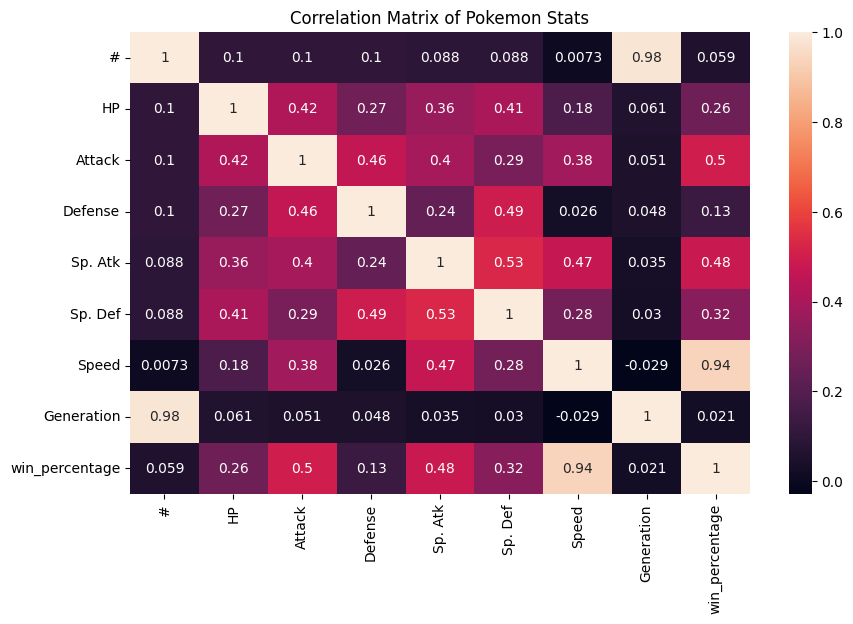

In [40]:

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Matrix of Pokemon Stats")
plt.show()

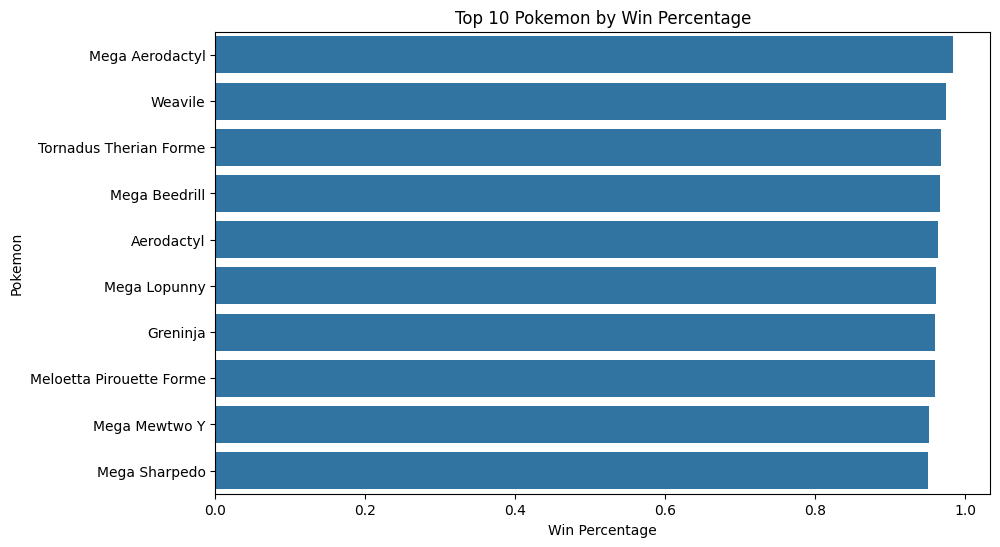

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_pokemon, x="win_percentage", y="Name")
plt.title("Top 10 Pokemon by Win Percentage")
plt.xlabel("Win Percentage")
plt.ylabel("Pokemon")
plt.show()

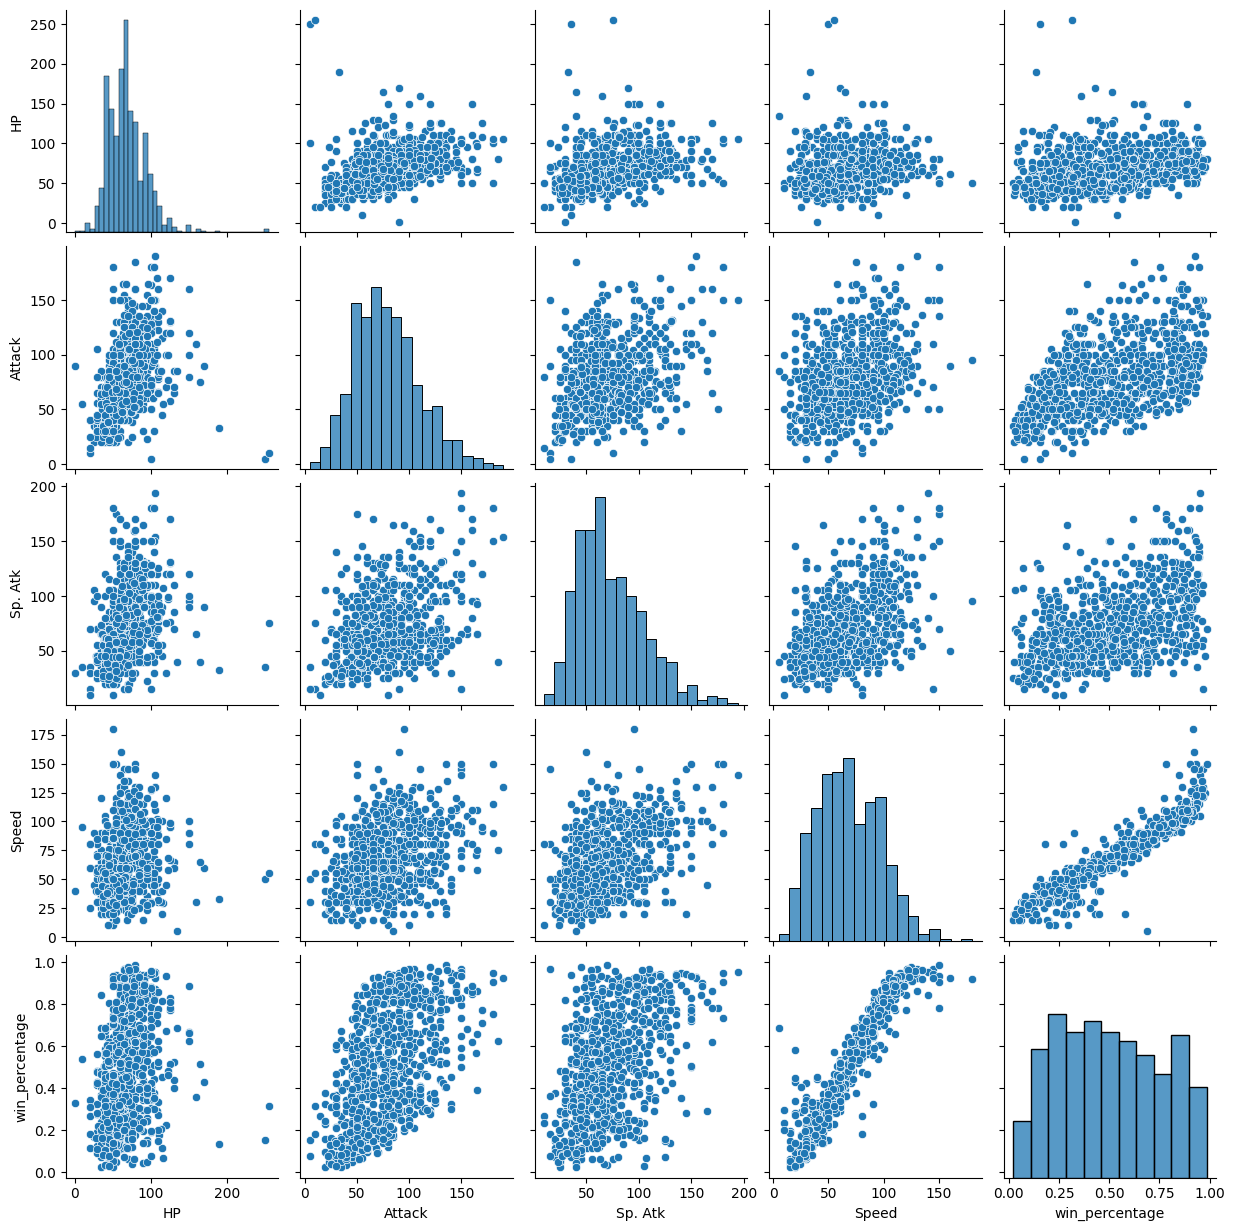

In [42]:
sns.pairplot(
    pokemon_model[["HP", "Attack", "Sp. Atk", "Speed", "win_percentage"]]
)
plt.show()

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [44]:
X = pokemon_model[["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Generation"]]
y = pokemon_model["win_percentage"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective="reg:squarederror")
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    results.append({"Model": name, "MAE": mae})

results_df = pd.DataFrame(results).sort_values(by="MAE")
results_df

,Model,MAE
1,Random Forest,0.042462
2,XGBoost,0.045295
0,Linear Regression,0.060837


Overall, Speed was the strongest predictor of Pokemon battle success. The correlation analysis showed that Speed had a very strong positive relationship with win percentage, while Attack and Special Attack also showed moderate relationships. The top 10 Pokemon by win percentage were mostly fast Pokemon with strong attacking stats. For machine learning, Random Forest gave the best performance based on MAE, making it the best model tested for predicting Pokemon win percentage.